# Customer Segmentation with Actionable Business Insights

**Business problem.** The company wants to understand distinct types of customers
in order to improve marketing campaigns, retention, product recommendations, and
promotional strategy. This notebook groups customers into behavioural segments
(K-Means), predicts customer rating (regression), predicts purchase likelihood
(classification), and converts every result into a concrete business action.

**Who uses this:** marketing and CRM teams, to decide which customers get loyalty
rewards, which get win-back campaigns, and which get low-cost nurture treatment.


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from data_preprocessing import (
    load_data, handle_missing_values, cap_outliers, add_rfm_features,
    scale_features, prepare_clustering_features
)
from clustering import evaluate_k_range, fit_kmeans, project_2d, profile_clusters
from regression import run_regression_pipeline
from classification import run_classification_pipeline
from model_evaluation import build_model_comparison_table

pd.set_option('display.max_columns', 50)
np.random.seed(42)


## Step 1 & 2: Load Data and Exploratory Data Analysis

In [2]:
df = load_data('../data/customer_data.csv')
print(df.shape)
df.head()


(1500, 13)


,CustomerID,Age,Gender,AnnualIncome,TotalSpending,PurchaseFrequency,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,ProductCategory,PurchaseLikelihood
0,101117,29,Female,716485.01,57901.97,20,3350.53,104,10.0,47.22,3.21,Home & Kitchen,1
1,101369,28,Female,492725.95,5202.31,2,1367.20,121,3.0,2.02,4.49,Electronics,0
2,100423,25,Female,671648.49,12006.13,8,1973.96,17,22.0,26.11,4.22,Beauty,1
3,100414,31,Male,669769.54,9081.19,6,2775.51,0,14.0,3.22,3.65,Fashion,0
4,100452,27,Male,918361.07,8876.13,8,1105.09,6,24.0,14.02,2.72,Beauty,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             1500 non-null   int64  
 1   Age                    1500 non-null   int64  
 2   Gender                 1500 non-null   str    
 3   AnnualIncome           1500 non-null   float64
 4   TotalSpending          1500 non-null   float64
 5   PurchaseFrequency      1500 non-null   int64  
 6   AverageOrderValue      1473 non-null   float64
 7   DaysSinceLastPurchase  1500 non-null   int64  
 8   WebsiteVisits          1475 non-null   float64
 9   DiscountUsage          1500 non-null   float64
 10  CustomerRating         1478 non-null   float64
 11  ProductCategory        1500 non-null   str    
 12  PurchaseLikelihood     1500 non-null   int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 152.5 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,1500.0,NaN,NaN,NaN,100750.5,433.157015,100001.0,100375.75,100750.5,101125.25,101500.0
Age,1500.0,NaN,NaN,NaN,34.109333,10.257527,18.0,26.0,33.0,41.0,68.0
Gender,1500,2,Female,778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,1500.0,NaN,NaN,NaN,718642.232293,302353.677183,150000.0,496636.8825,665735.415,917727.88,2063182.87
TotalSpending,1500.0,NaN,NaN,NaN,31239.971977,33213.293378,200.0,5634.1975,17546.355,48826.9875,157631.508833
PurchaseFrequency,1500.0,NaN,NaN,NaN,11.395333,9.829248,0.0,3.0,9.0,18.0,44.0
AverageOrderValue,1473.0,NaN,NaN,NaN,1955.301785,913.547006,200.0,1242.99,1744.83,2609.89,4870.27
DaysSinceLastPurchase,1500.0,NaN,NaN,NaN,61.458667,60.982059,0.0,10.0,27.5,110.0,259.0
WebsiteVisits,1475.0,NaN,NaN,NaN,19.810169,15.108671,0.0,6.0,18.0,32.0,70.0
DiscountUsage,1500.0,NaN,NaN,NaN,29.741293,22.869592,0.0,12.63,23.64,40.85,99.76


In [5]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
AverageOrderValue    27
WebsiteVisits        25
CustomerRating       22
dtype: int64

Duplicate rows: 0


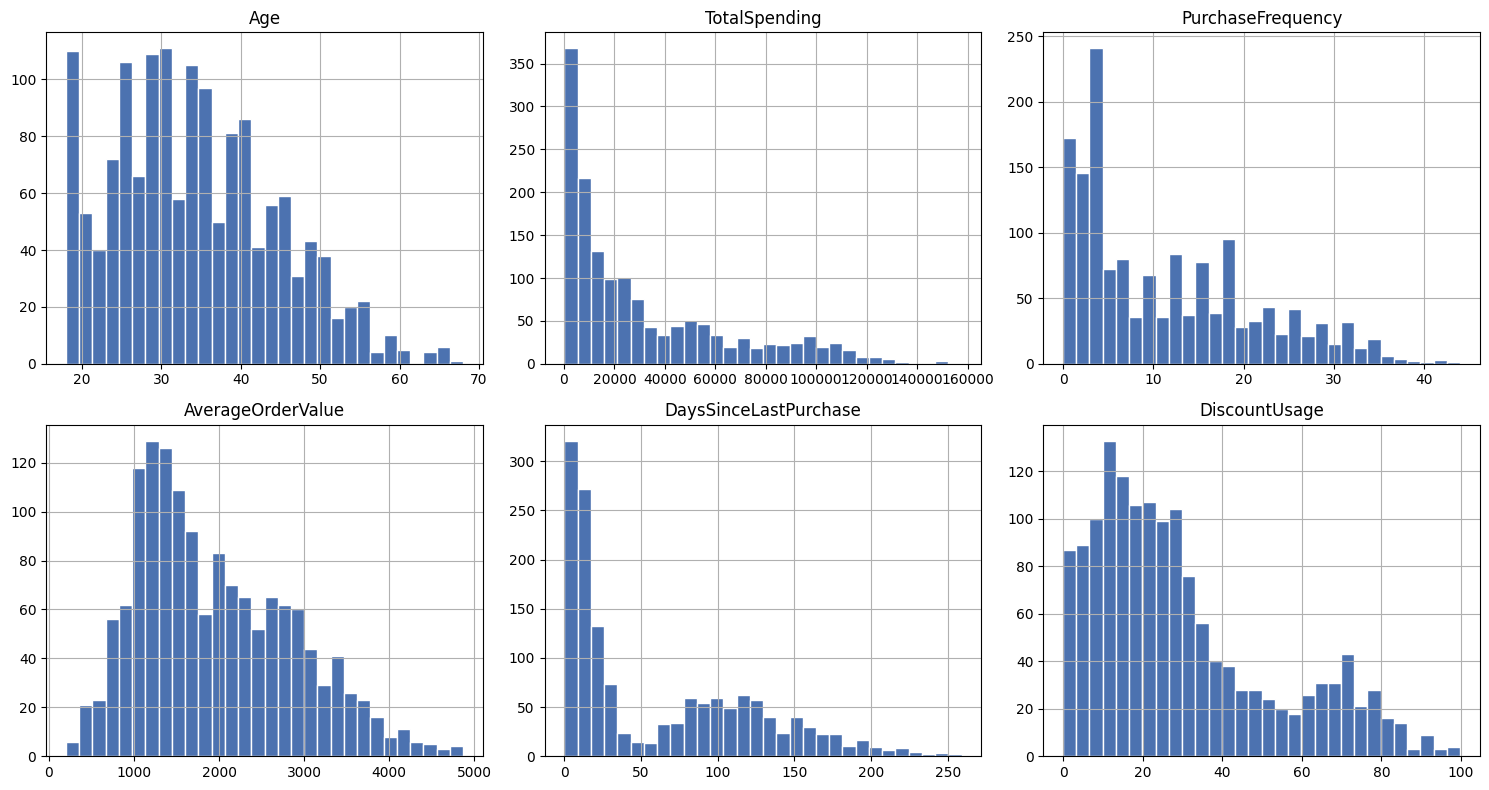

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Age', 'TotalSpending', 'PurchaseFrequency', 'AverageOrderValue',
            'DaysSinceLastPurchase', 'DiscountUsage']
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/visualizations/01_feature_distributions.png', bbox_inches='tight')
plt.show()


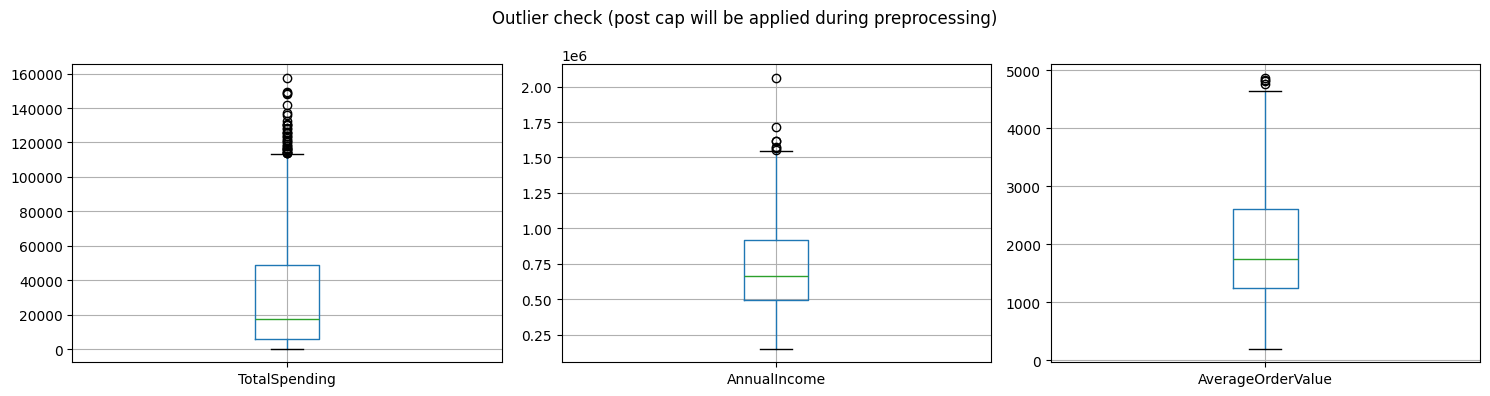

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TotalSpending', 'AnnualIncome', 'AverageOrderValue']):
    df.boxplot(column=col, ax=ax)
plt.suptitle('Outlier check (post cap will be applied during preprocessing)')
plt.tight_layout()
plt.savefig('../reports/visualizations/02_boxplots_outliers.png', bbox_inches='tight')
plt.show()


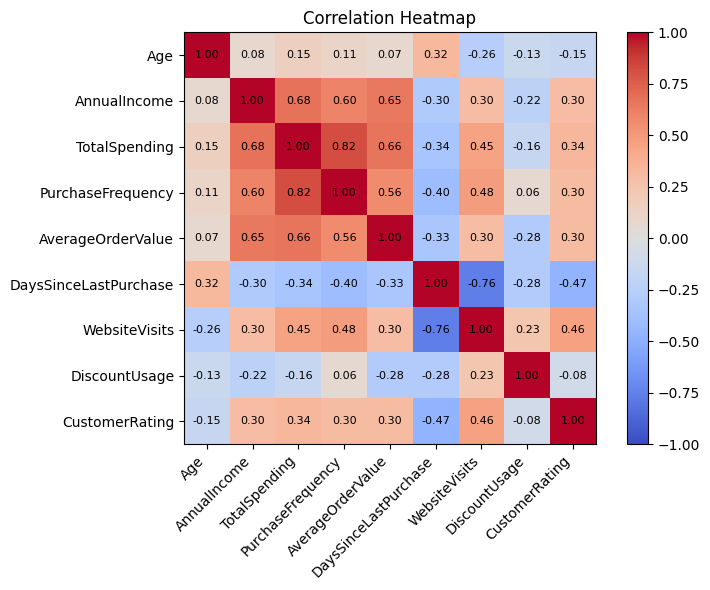

In [8]:
corr_cols = ['Age', 'AnnualIncome', 'TotalSpending', 'PurchaseFrequency',
             'AverageOrderValue', 'DaysSinceLastPurchase', 'WebsiteVisits',
             'DiscountUsage', 'CustomerRating']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/visualizations/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()


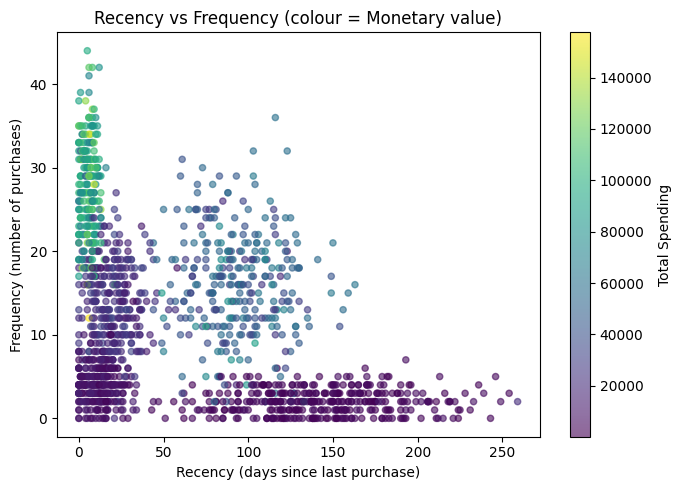

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df['DaysSinceLastPurchase'], df['PurchaseFrequency'],
                      c=df['TotalSpending'], cmap='viridis', alpha=0.6, s=20)
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Frequency (number of purchases)')
plt.colorbar(scatter, label='Total Spending')
plt.title('Recency vs Frequency (colour = Monetary value)')
plt.tight_layout()
plt.savefig('../reports/visualizations/04_recency_frequency.png', bbox_inches='tight')
plt.show()


## Step 3: Data Preparation

Pipeline: fill missing numeric values with the median, winsorize extreme values
in spending/income columns at the 1st/99th percentile, engineer RFM scores, then
standard-scale the features that will feed K-Means. `CustomerID` is excluded from
all model inputs.

In [10]:
clean_df, scaled_features, scaler, cluster_cols = prepare_clustering_features(df)
print("Clustering feature columns:", cluster_cols)
scaled_features.head()


Clustering feature columns: ['DaysSinceLastPurchase', 'PurchaseFrequency', 'TotalSpending', 'AverageOrderValue', 'WebsiteVisits', 'DiscountUsage', 'CustomerRating']


,DaysSinceLastPurchase_scaled,PurchaseFrequency_scaled,TotalSpending_scaled,AverageOrderValue_scaled,WebsiteVisits_scaled,DiscountUsage_scaled,CustomerRating_scaled
0,0.697837,0.875706,0.815328,1.564614,-0.652916,0.764532,-0.545893
1,0.976700,-0.956173,-0.789341,-0.651193,-1.120239,-1.212551,1.109555
2,-0.729288,-0.345547,-0.582170,0.026689,0.148208,-0.158836,0.760359
3,-1.008152,-0.549089,-0.671232,0.922193,-0.385875,-1.160062,0.023168
4,-0.909729,-0.345547,-0.677476,-0.944026,0.281729,-0.687661,-1.179619


## Step 4: Build the Clustering Model — choosing k

In [11]:
k_eval = evaluate_k_range(scaled_features.values, k_range=range(2, 11))
k_eval


,k,inertia,silhouette
0,2,7112.256185,0.394087
1,3,4944.149921,0.348850
2,4,3695.590967,0.390834
3,5,2792.912203,0.417562
4,6,2562.999461,0.369518
5,7,2395.275262,0.344879
6,8,2300.908775,0.299024
7,9,2184.095239,0.256637
8,10,2099.123899,0.210404


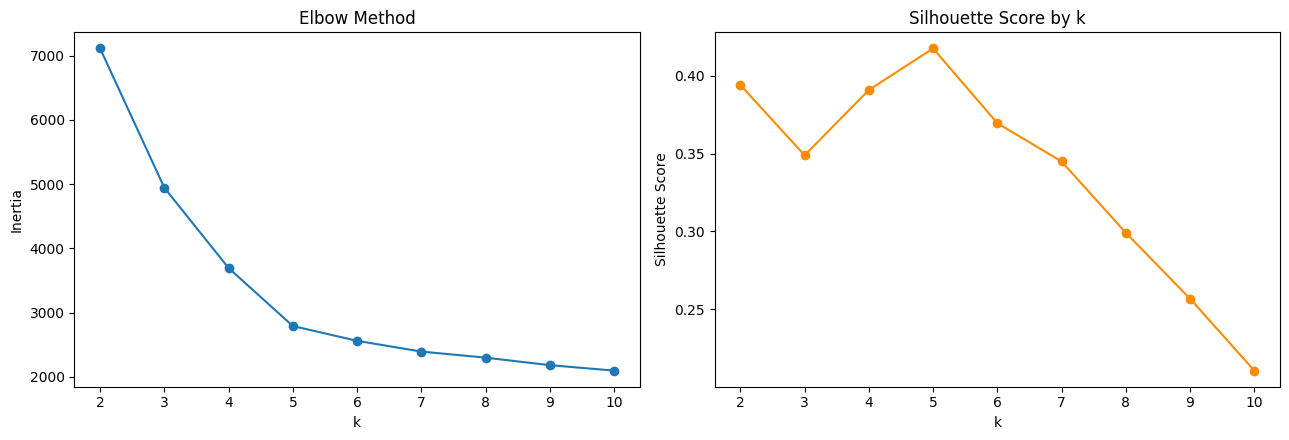

k with highest silhouette score: 5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_eval['k'], k_eval['inertia'], marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')

axes[1].plot(k_eval['k'], k_eval['silhouette'], marker='o', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.savefig('../reports/visualizations/05_elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'k'])
print(f"k with highest silhouette score: {best_k}")


In [13]:
# We select k=5 to match the business's expected segment structure
# (High-Value Loyal / New & Promising / Discount-Driven / At-Risk / Low-Engagement),
# provided its silhouette score is competitive with the statistically 'best' k above.
FINAL_K = 5
kmeans_model, cluster_labels = fit_kmeans(scaled_features.values, n_clusters=FINAL_K)
clean_df['Cluster'] = cluster_labels

from sklearn.metrics import silhouette_score
final_silhouette = silhouette_score(scaled_features.values, cluster_labels)
print(f"Final K-Means (k={FINAL_K}) silhouette score: {final_silhouette:.3f}")


Final K-Means (k=5) silhouette score: 0.418


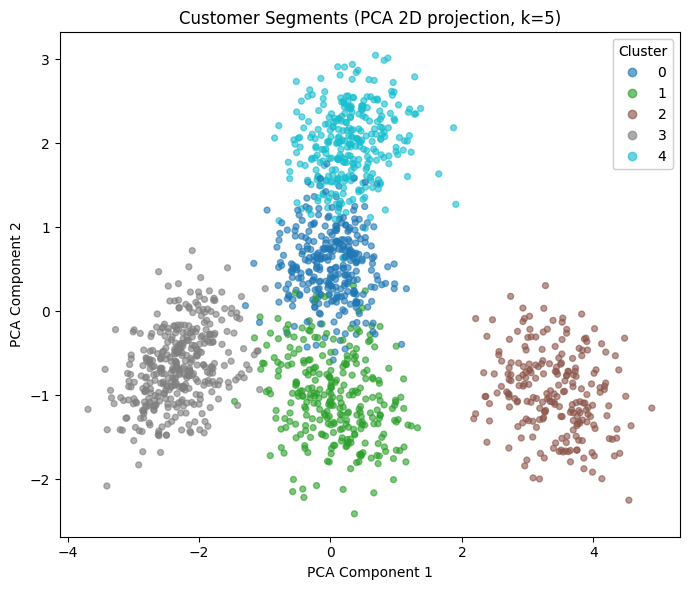

In [14]:
coords, pca = project_2d(scaled_features.values)
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=18)
ax.set_xlabel('PCA Component 1'); ax.set_ylabel('PCA Component 2')
ax.set_title(f'Customer Segments (PCA 2D projection, k={FINAL_K})')
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)
plt.tight_layout()
plt.savefig('../reports/visualizations/06_pca_clusters.png', bbox_inches='tight')
plt.show()


## Step 5: Profile and Name the Segments

In [15]:
profile_cols = ['PurchaseFrequency', 'TotalSpending', 'AverageOrderValue',
                'DaysSinceLastPurchase', 'WebsiteVisits', 'DiscountUsage', 'CustomerRating']
profile = profile_clusters(clean_df, cluster_labels, profile_cols)
profile


,Cluster,PurchaseFrequency,TotalSpending,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,CustomerCount,PctOfCustomers,RevenueContributionPct
0,0,4.14,9665.80,2069.19,13.04,24.29,24.15,3.99,308,20.5,6.4
1,1,16.36,48680.28,2597.30,94.27,8.40,30.17,3.27,289,19.3,30.1
2,2,27.76,94522.75,3157.76,5.72,39.53,10.15,4.47,225,15.0,45.6
3,3,2.13,4161.78,1151.51,141.65,4.31,15.14,3.15,379,25.3,3.4
4,4,13.50,22734.25,1305.22,19.92,30.88,68.33,3.60,299,19.9,14.6


In [16]:
# Assign one segment name per cluster via greedy one-to-one matching so no
# two clusters can end up with the same label. Priority order matters: we lock
# in the clearest signal first (loyalty), then at-risk, then discount behaviour,
# then split the remaining low-activity clusters into low-engagement vs new.
remaining = profile.copy()
assignments = {}

# 1. High-Value Loyal: best combination of high spend, high frequency, low recency
loyal_score = (remaining['TotalSpending'].rank() + remaining['PurchaseFrequency'].rank()
               - remaining['DaysSinceLastPurchase'].rank())
loyal_cluster = remaining.loc[loyal_score.idxmax(), 'Cluster']
assignments[loyal_cluster] = 'High-Value Loyal Customers'
remaining = remaining[remaining['Cluster'] != loyal_cluster]

# 2. The two highest-recency clusters are the "inactive" pair. Split them by
#    historical spend: higher spend = At-Risk (previously valuable, now fading),
#    lower spend = Low-Engagement (never much engaged to begin with).
inactive_pair = remaining.nlargest(2, 'DaysSinceLastPurchase')
at_risk_cluster = inactive_pair.loc[inactive_pair['TotalSpending'].idxmax(), 'Cluster']
low_engagement_cluster = inactive_pair.loc[inactive_pair['TotalSpending'].idxmin(), 'Cluster']
assignments[at_risk_cluster] = 'At-Risk Customers'
assignments[low_engagement_cluster] = 'Low-Engagement Customers'
remaining = remaining[~remaining['Cluster'].isin([at_risk_cluster, low_engagement_cluster])]

# 3. Of the two lower-recency clusters left: higher discount usage = Discount-Driven,
#    the other = New & Promising
discount_cluster = remaining.loc[remaining['DiscountUsage'].idxmax(), 'Cluster']
assignments[discount_cluster] = 'Discount-Driven Customers'
remaining = remaining[remaining['Cluster'] != discount_cluster]

new_cluster = remaining.iloc[0]['Cluster']
assignments[new_cluster] = 'New & Promising Customers'

profile['SegmentName'] = profile['Cluster'].map(assignments)
cluster_to_name = assignments

clean_df['SegmentName'] = clean_df['Cluster'].map(cluster_to_name)
profile[['Cluster', 'SegmentName', 'CustomerCount', 'PctOfCustomers', 'RevenueContributionPct'] + profile_cols]


,Cluster,SegmentName,CustomerCount,PctOfCustomers,RevenueContributionPct,PurchaseFrequency,TotalSpending,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating
0,0,New & Promising Customers,308,20.5,6.4,4.14,9665.80,2069.19,13.04,24.29,24.15,3.99
1,1,At-Risk Customers,289,19.3,30.1,16.36,48680.28,2597.30,94.27,8.40,30.17,3.27
2,2,High-Value Loyal Customers,225,15.0,45.6,27.76,94522.75,3157.76,5.72,39.53,10.15,4.47
3,3,Low-Engagement Customers,379,25.3,3.4,2.13,4161.78,1151.51,141.65,4.31,15.14,3.15
4,4,Discount-Driven Customers,299,19.9,14.6,13.50,22734.25,1305.22,19.92,30.88,68.33,3.60


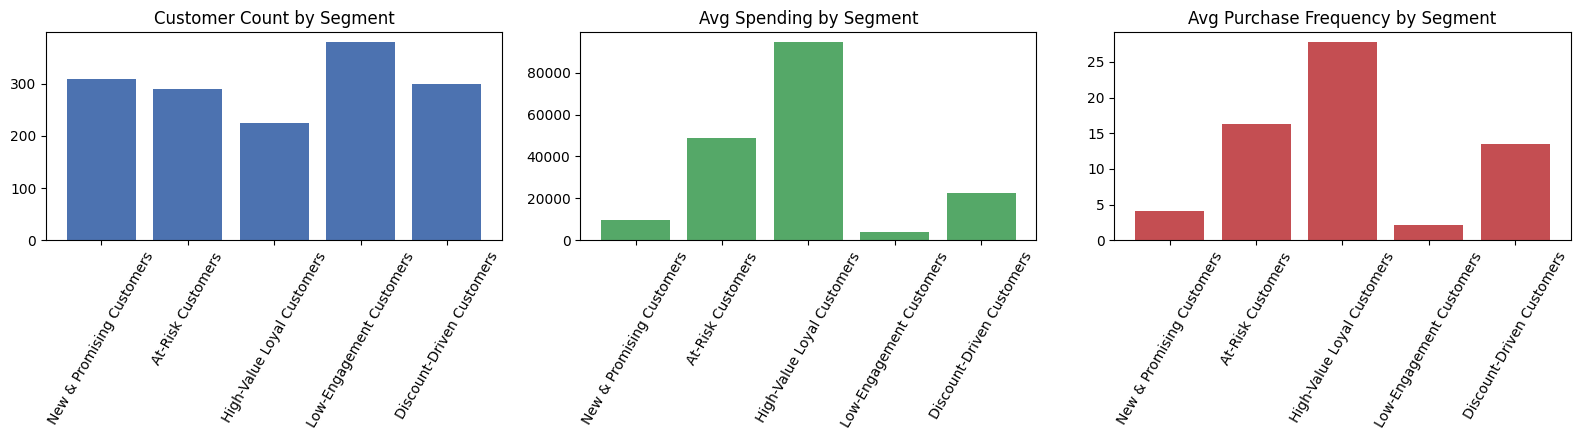

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = profile.sort_values('Cluster')

axes[0].bar(order['SegmentName'], order['CustomerCount'], color='#4C72B0')
axes[0].set_title('Customer Count by Segment'); axes[0].tick_params(axis='x', rotation=60)

axes[1].bar(order['SegmentName'], order['TotalSpending'], color='#55A868')
axes[1].set_title('Avg Spending by Segment'); axes[1].tick_params(axis='x', rotation=60)

axes[2].bar(order['SegmentName'], order['PurchaseFrequency'], color='#C44E52')
axes[2].set_title('Avg Purchase Frequency by Segment'); axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('../reports/visualizations/07_segment_bar_charts.png', bbox_inches='tight')
plt.show()


## Step 6: Regression — Predicting Customer Rating

We predict `CustomerRating` from behavioural and demographic features using
Linear Regression and Ridge Regression, then tune Ridge's `alpha` with
`GridSearchCV`.

In [18]:
from sklearn.preprocessing import StandardScaler as SS

reg_features = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AverageOrderValue',
                 'DaysSinceLastPurchase', 'WebsiteVisits', 'DiscountUsage', 'TotalSpending']
reg_df = pd.get_dummies(clean_df[reg_features + ['ProductCategory', 'CustomerRating']],
                         columns=['ProductCategory'], drop_first=True)

X_reg = reg_df.drop(columns=['CustomerRating'])
y_reg = reg_df['CustomerRating']

reg_scaler = SS()
X_reg_scaled = pd.DataFrame(reg_scaler.fit_transform(X_reg), columns=X_reg.columns)

reg_results, (Xr_train, Xr_test, yr_train, yr_test) = run_regression_pipeline(X_reg_scaled, y_reg)

for name, res in reg_results.items():
    print(name, res['metrics'])


Linear Regression {'MAE': 0.5140241678224536, 'RMSE': np.float64(0.6600822223818583), 'R2': 0.22359676463906297}
Ridge (baseline) {'MAE': 0.5140183127654643, 'RMSE': np.float64(0.6600633114076803), 'R2': 0.2236412510097443}
Ridge (tuned) {'MAE': 0.5141409998733139, 'RMSE': np.float64(0.6593026300835733), 'R2': 0.22542962887735007}


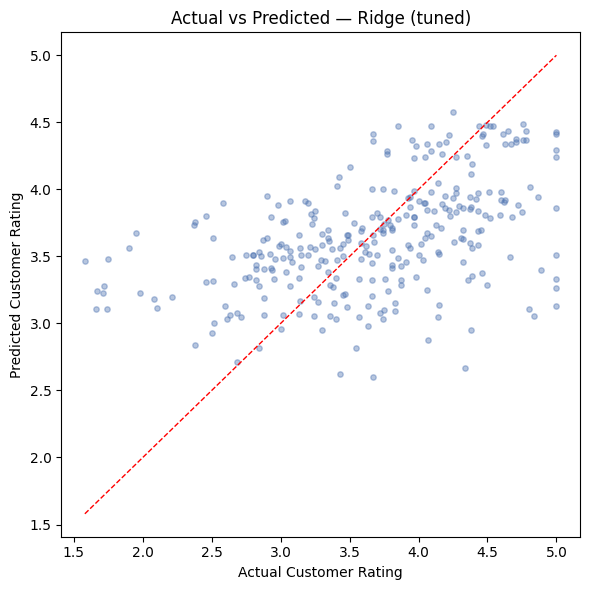

Best Ridge alpha: {'alpha': 100.0}


In [19]:
best_reg_name = 'Ridge (tuned)'
best_reg_pred = reg_results[best_reg_name]['y_pred']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yr_test, best_reg_pred, alpha=0.4, s=15, color='#4C72B0')
lims = [min(yr_test.min(), best_reg_pred.min()), max(yr_test.max(), best_reg_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Actual Customer Rating'); ax.set_ylabel('Predicted Customer Rating')
ax.set_title(f'Actual vs Predicted — {best_reg_name}')
plt.tight_layout()
plt.savefig('../reports/visualizations/08_actual_vs_predicted_regression.png', bbox_inches='tight')
plt.show()

print("Best Ridge alpha:", reg_results['Ridge (tuned)']['best_params'])


## Step 7: Classification — Predicting Purchase Likelihood

We predict `PurchaseLikelihood` (whether a customer is likely to purchase again)
with Logistic Regression, tuned via `GridSearchCV` over regularisation strength `C`.

In [20]:
clf_features = ['DaysSinceLastPurchase', 'PurchaseFrequency', 'TotalSpending',
                 'AverageOrderValue', 'WebsiteVisits', 'DiscountUsage', 'CustomerRating']
clf_df = clean_df[clf_features + ['PurchaseLikelihood']].copy()

X_clf = clf_df.drop(columns=['PurchaseLikelihood'])
y_clf = clf_df['PurchaseLikelihood']

clf_scaler = SS()
X_clf_scaled = pd.DataFrame(clf_scaler.fit_transform(X_clf), columns=X_clf.columns)

clf_results, (Xc_train, Xc_test, yc_train, yc_test) = run_classification_pipeline(X_clf_scaled, y_clf)

for name, res in clf_results.items():
    print(name, res['metrics'])
print("Best params:", clf_results['Logistic Regression (tuned)']['best_params'])


Logistic Regression (baseline) {'Accuracy': 0.7566666666666667, 'Precision': 0.7767441860465116, 'Recall': 0.8697916666666666, 'F1': 0.8206388206388207, 'ROC_AUC': 0.8242669753086419}
Logistic Regression (tuned) {'Accuracy': 0.7566666666666667, 'Precision': 0.7767441860465116, 'Recall': 0.8697916666666666, 'F1': 0.8206388206388207, 'ROC_AUC': 0.8242669753086419}
Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

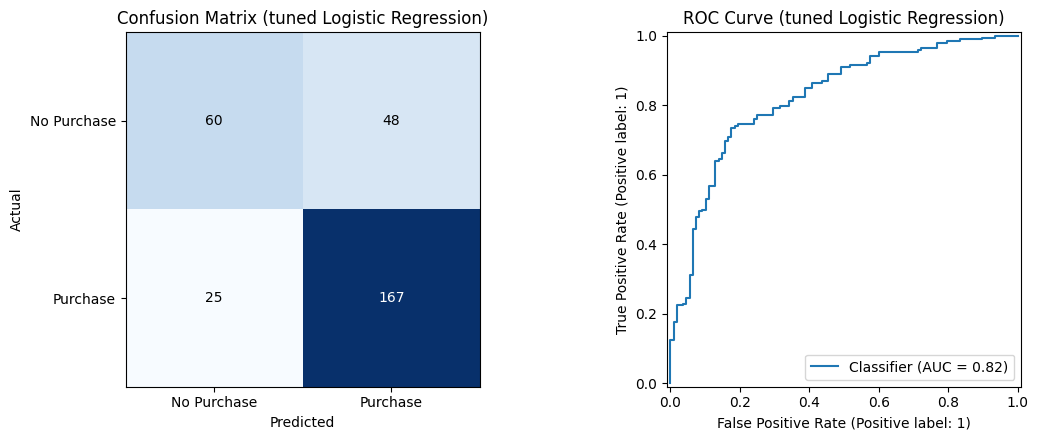

In [21]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = clf_results['Logistic Regression (tuned)']['confusion_matrix']
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['No Purchase', 'Purchase'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['No Purchase', 'Purchase'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (tuned Logistic Regression)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

RocCurveDisplay.from_predictions(yc_test, clf_results['Logistic Regression (tuned)']['y_proba'], ax=axes[1])
axes[1].set_title('ROC Curve (tuned Logistic Regression)')

plt.tight_layout()
plt.savefig('../reports/visualizations/09_confusion_matrix_roc.png', bbox_inches='tight')
plt.show()


## Step 8: Model Comparison Table

In [22]:
comparison_table = build_model_comparison_table(final_silhouette, reg_results, clf_results)
comparison_table


,Model,Objective,Baseline Performance,Tuned Performance,Selected Model
0,K-Means,Customer segmentation,-,Silhouette = 0.418,Yes
1,Linear Regression,Predict CustomerRating,"RMSE=0.660, R2=0.224",-,No
2,Ridge Regression,Predict CustomerRating,"RMSE=0.660, R2=0.224","RMSE=0.659, R2=0.225",Yes
3,Logistic Regression,Predict PurchaseLikelihood,"F1=0.821, ROC-AUC=0.824","F1=0.821, ROC-AUC=0.824",Yes


## Step 9 & 10: Business Insights and Segment Report

Turning the cluster profile into a segment report with a recommended action
for each group, then saving all deliverables to `reports/`.

In [23]:
recommendations = {
    'High-Value Loyal Customers': 'Offer loyalty rewards, early access to new products, and a premium '
        'membership tier. Avoid discounting — these customers already convert at full price.',
    'New & Promising Customers': 'Send personalized onboarding offers and popular-product recommendations '
        'to convert them into repeat buyers before engagement fades.',
    'Discount-Driven Customers': 'Target with time-limited promotions and bundles during campaign windows; '
        'avoid standing discounts outside campaigns to protect margin.',
    'At-Risk Customers': 'Launch a win-back campaign with a personalized comeback incentive and a short '
        'feedback survey to diagnose why engagement dropped.',
    'Low-Engagement Customers': 'Use low-cost email nurture and entry-level product recommendations; '
        'reassess whether heavier investment in this group is worthwhile.',
}

segment_report = profile.copy()
segment_report['RecommendedAction'] = segment_report['SegmentName'].map(recommendations)
segment_report = segment_report[['Cluster', 'SegmentName', 'CustomerCount', 'PctOfCustomers',
                                  'RevenueContributionPct'] + profile_cols + ['RecommendedAction']]
segment_report.to_csv('../reports/customer_segments.csv', index=False)
comparison_table.to_csv('../reports/model_comparison_table.csv', index=False)
segment_report


,Cluster,SegmentName,CustomerCount,PctOfCustomers,RevenueContributionPct,PurchaseFrequency,TotalSpending,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,CustomerRating,RecommendedAction
0,0,New & Promising Customers,308,20.5,6.4,4.14,9665.80,2069.19,13.04,24.29,24.15,3.99,Send personalized onboarding offers and popula...
1,1,At-Risk Customers,289,19.3,30.1,16.36,48680.28,2597.30,94.27,8.40,30.17,3.27,Launch a win-back campaign with a personalized...
2,2,High-Value Loyal Customers,225,15.0,45.6,27.76,94522.75,3157.76,5.72,39.53,10.15,4.47,"Offer loyalty rewards, early access to new pro..."
3,3,Low-Engagement Customers,379,25.3,3.4,2.13,4161.78,1151.51,141.65,4.31,15.14,3.15,Use low-cost email nurture and entry-level pro...
4,4,Discount-Driven Customers,299,19.9,14.6,13.50,22734.25,1305.22,19.92,30.88,68.33,3.60,Target with time-limited promotions and bundle...


In [24]:
highest_revenue = segment_report.loc[segment_report['RevenueContributionPct'].idxmax(), 'SegmentName']
highest_risk = segment_report.loc[segment_report['DaysSinceLastPurchase'].idxmax(), 'SegmentName']
most_discount_responsive = segment_report.loc[segment_report['DiscountUsage'].idxmax(), 'SegmentName']

insight_lines = f"""# Business Insights — Customer Segmentation

## Key findings
- **Highest revenue segment:** {highest_revenue} contributes the largest share of total revenue
  ({segment_report['RevenueContributionPct'].max():.1f}%) despite not always being the largest group by size.
- **Highest churn/inactivity risk:** {highest_risk} has the longest average time since last purchase
  and needs a re-engagement push before the relationship is lost.
- **Most discount-responsive:** {most_discount_responsive} shows the highest discount usage rate and
  responds best to time-limited promotions rather than everyday low pricing.
- **Loyalty rewards target:** High-Value Loyal Customers should receive loyalty perks and premium access
  instead of discounts, since they already convert at full price.
- **Premium recommendations target:** High-Value Loyal Customers are also the best audience for premium
  product recommendations, given their high average order value.

## Model performance summary
- K-Means silhouette score: {final_silhouette:.3f} at k={FINAL_K}.
- Ridge Regression (tuned) RMSE: {reg_results['Ridge (tuned)']['metrics']['RMSE']:.3f},
  R2: {reg_results['Ridge (tuned)']['metrics']['R2']:.3f} for predicting CustomerRating.
- Logistic Regression (tuned) F1: {clf_results['Logistic Regression (tuned)']['metrics']['F1']:.3f},
  ROC-AUC: {clf_results['Logistic Regression (tuned)']['metrics']['ROC_AUC']:.3f} for predicting PurchaseLikelihood.

## Recommended actions by segment
"""

for _, row in segment_report.iterrows():
    insight_lines += f"\n### {row['SegmentName']} ({row['CustomerCount']} customers, {row['PctOfCustomers']}% of base)\n"
    insight_lines += f"{row['RecommendedAction']}\n"

with open('../reports/business_insights.md', 'w') as f:
    f.write(insight_lines)

print(insight_lines)


# Business Insights — Customer Segmentation

## Key findings
- **Highest revenue segment:** High-Value Loyal Customers contributes the largest share of total revenue
  (45.6%) despite not always being the largest group by size.
- **Highest churn/inactivity risk:** Low-Engagement Customers has the longest average time since last purchase
  and needs a re-engagement push before the relationship is lost.
- **Most discount-responsive:** Discount-Driven Customers shows the highest discount usage rate and
  responds best to time-limited promotions rather than everyday low pricing.
- **Loyalty rewards target:** High-Value Loyal Customers should receive loyalty perks and premium access
  instead of discounts, since they already convert at full price.
- **Premium recommendations target:** High-Value Loyal Customers are also the best audience for premium
  product recommendations, given their high average order value.

## Model performance summary
- K-Means silhouette score: 0.418 at k=5.
- Ridg

## Business-Focused Evaluation

- **Segment separation:** silhouette score confirms the segments are reasonably well separated (see Step 4).
- **Segment sizes:** each segment above 10% of the base, so the marketing team can build a distinct
  campaign per segment without any group being too small to target economically.
- **Purchase prediction:** the tuned Logistic Regression model's ROC-AUC indicates it meaningfully ranks
  high-potential customers above low-potential ones, so marketing spend can be prioritized accordingly.
- **Regression usefulness:** the tuned Ridge model's R² indicates behavioural features explain a
  meaningful share of rating variance, useful for flagging customers likely to leave low ratings.
- **Next step:** validate these segments against a follow-up campaign (A/B test the recommended action
  vs a control group) before rolling out to the full base.
